In [1]:
import cobra
import pycomo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pycomo.configure_logger(level="error")

2026-08-13 14:42:10,472 - PyCoMo - INFO - Logger initialized.


In [2]:
models = ["Rhodoferax", "Geobacter"]
for modelname in models:
    model = cobra.io.load_matlab_model(f"../models/{modelname}.mat")
    to_remove = []
    for rxn in model.reactions:
        if abs(rxn.lower_bound) < 1e-15 and abs(rxn.upper_bound) < 1e-15:
            print(f"{rxn.id} removed\n")
            to_remove.append(rxn)
    model.remove_reactions(to_remove)

    if modelname == "Geobacter":
        to_remove = [rxn.id for rxn in model.reactions if rxn.id.startswith("DM_")]
        model.remove_reactions(to_remove)
        model.reactions.ATPM.bounds = (0.,1000.)

    cobra.manipulation.delete.prune_unused_metabolites(model)

    cobra.io.write_sbml_model(model, f"../models/original_models/{modelname}.xml")

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e


FUMt4 removed



In [3]:
common_uptakes = ['so4', 'pi', 'mg2', 'k', 'ca2', 'h', 'h2', 'h2o']

dimes = {"Rhodoferax": {
            "mEmC_1": {"uptakes": ["nh4", "fe2", "fum", "o2"],
                        "secretion": ["mal_L",  "co2"]},
            "mEmC_3": {"uptakes": ["nh4", "fe2", "fum", "o2"],
                        "secretion": ["mal_L",  "co2"]},
    
            "mEmC_2": {"uptakes": ["nh4", "fe2", "cit", "o2"],
                "secretion": ["mal_L",  "co2"]},
            "mEmC_4": {"uptakes": ["nh4", "fe2", "cit", "o2"],
                "secretion": ["mal_L",  "co2"]},

            "mEmC_5": {"uptakes": ["nh4", "fe2", "mal_L", "o2"],
                "secretion": ["co2"]},
            "mEmC_6": {"uptakes": ["nh4", "fe2", "mal_L", "o2", "co2"],
                      "secretion": []},
            "mE_1": {"uptakes": ["nh4", "ac", "fe3", "o2"],
                    "secretion": ["co2"]},
},
        "Geobacter": {
            "mEmC_1": {"uptakes": ["nh4", "fe3", "mal_L"],
                      "secretion": ["fe2", "co2", "h2s"]},
            "mEmC_2": {"uptakes": ["nh4", "fe3", "mal_L"],
                      "secretion": ["fe2", "co2", "h2s"]},
            "mEmC_3": {"uptakes": ["n2", "fe3", "mal_L"],
                      "secretion": ["fe2", "co2", "h2s"]},
            "mEmC_4": {"uptakes": ["n2", "fe3", "mal_L"],
                      "secretion": ["fe2", "co2", "h2s"]},
            "mEmC_5": {"uptakes": ["n2", "fe3", "cit"],
                      "secretion": ["fe2", "mal_L", "co2", "h2s"]},
            "mEmC_6": {"uptakes": ["n2", "fe3", "cit"],
                      "secretion": ["fe2", "mal_L", "co2", "h2s"]},
            "mE_1": {"uptakes": ["n2", "fe3", "mal_L"],
                  "secretion": ["fe2", "ac", "co2", "h2s"]},
    }}

crossfed = {"mEmC_1": ["mal_L", "fe2"],
          "mEmC_2": ["mal_L", "fe2"],
          "mEmC_3": ["mal_L", "fe2"],
          "mEmC_4": ["mal_L", "fe2"],
          "mEmC_5": ["mal_L", "fe2"],
          "mEmC_6": ["mal_L", "co2",  "fe2"],
          "mE_1": ["ac"]}

main_c_source = {"mEmC_1": {"c_source": "fum", "feeder": "Rhodoferax", 
                            "receiver": "Geobacter", "crossfed": "mal_L"},
                 "mEmC_2": {"c_source": "cit", "feeder": "Rhodoferax",
                            "receiver": "Geobacter", "crossfed": "mal_L"},
                 "mEmC_3": {"c_source": "fum", "feeder": "Rhodoferax",
                            "receiver": "Geobacter", "crossfed": "mal_L"},
                 "mEmC_4": {"c_source": "cit", "feeder": "Rhodoferax",
                            "receiver": "Geobacter", "crossfed": "mal_L"},
                 "mEmC_5": {"c_source": "cit", "feeder": "Geobacter", 
                            "receiver": "Rhodoferax", "crossfed": "mal_L"},
                 "mEmC_6": {"c_source": "cit", "feeder": "Geobacter",
                            "receiver": "Rhodoferax", "crossfed": "mal_L"},
                 "mE_1":   {"c_source": "mal_L", "feeder": "Geobacter",
                            "receiver": "Rhodoferax", "crossfed": "ac"}}


In [4]:
model_dir = "../models/original_models"
named_models = pycomo.load_named_models_from_dir(model_dir)
single_org_models = []
for modelname, model in named_models.items():
    print(modelname, model.slim_optimize())

    single_org_model = pycomo.SingleOrganismModel(model, modelname)
    single_org_models.append(single_org_model)

Rhodoferax 41.91559360486998
Geobacter 35.65356530827638


In [5]:
def get_medium_for_pattern(pattern, dimes, 
                           c_sources, crossfed, models):
    # basic medium
    medium = {
        'EX_so4_medium': 1000.,
        'EX_pi_medium': 1000.,
        'EX_mg2_medium': 1000.,
        'EX_k_medium': 1000.,
        'EX_ca2_medium': 1000.,
        'EX_h_medium': 1000.,
        'EX_h2_medium': 1000.,
        'EX_h2o_medium': 1000.}

    for modelname in models:
        for component in dimes[modelname][pattern]["uptakes"]:
            max_uptake = 1000.
            if component in c_sources:
                max_uptake = 10.
            if component in crossfed[pattern]:
                continue
    
            medium_name = f"EX_{component}_medium"
            medium[medium_name] = max_uptake
    return medium

In [6]:
def implement_dime(pattern, dimes, com_model):
    for rxn in com_model.transfer_reactions:
        for organism in ["Geobacter", "Rhodoferax"]:
            if organism in rxn.id:
                individual_uptakes = dimes[organism][pattern]["uptakes"]
    
                # allow uptakes from medium too
                if any(f"_{met}_" in rxn.id for met in common_uptakes):
                    rxn.lower_bound = -1000
                    rxn.upper_bound = 1000
                    #print(f"{rxn.id} taken up/secreted")
                elif any(f"_{met}_" in rxn.id for met in individual_uptakes):
                    rxn.lower_bound = -1000
                    rxn.upper_bound = 0
                    #print(f"{rxn.id} taken up")
                else:
                    rxn.lower_bound = 0
                    rxn.upper_bound = 1000
                    #print(f"{rxn.id} secreted")


In [7]:
def get_compositions(com_model, mus, organism="Geobacter"):
    mins = []
    maxs = []
    feasible_mus = []

    for mu in mus:
        try:
            comps = com_model.feasible_composition_range(mu)
        except Exception as e:
            print(f"Growth rate {mu} infeasible")
            break
            
        feasible_mus.append(mu)
        geo = comps.loc[comps.reaction_id == f"{organism}_fraction_reaction"]
        mins.append(geo.min_flux.item())
        maxs.append(geo.max_flux.item())

    return feasible_mus, mins, maxs

def plot_compositions(mus, mins, maxs, organism="Geobacter", title=""):
    color = "#00a797" # "#d43689"

    plt.fill_betweenx(mus, mins, maxs, alpha = 0.5, color = color)
    plt.xlabel(f"Fraction of {organism}", size=15)
    plt.ylabel("Growth rate", size=15)
    plt.title(title)
    plt.savefig(f"../figures/{title}.png", dpi=300, bbox_inches="tight")
    plt.show()


In [8]:
community_name = "uranium_community"
com_model_orig = pycomo.CommunityModel(single_org_models, community_name)
com_model_orig.model.solver = "cplex"
com_model_orig.model.tolerance = 1e-9

In [9]:
com_model_orig.max_growth_rate(return_abundances=True, minimal_abundance=0.1)

2026-08-13 14:42:19,121 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:20,414 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:22,490 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:23,820 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:25,557 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:26,987 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:28,790 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:30,124 - PyCoMo - INFO - Logger initialized.


,reaction_id,min_flux,max_flux
0,Rhodoferax_fraction_reaction,0.000000,1.000000
1,Geobacter_fraction_reaction,0.000000,1.000000
2,community_biomass,41.915593,41.915593


In [10]:
com_model_orig.model.reactions.Geobacter_TF_co2_Geobacter_e

Reaction identifier,Geobacter_TF_co2_Geobacter_e
Name,EX_co2(e)
Memory address,0x7fce091b3f10
Stoichiometry,0.01 Geobacter_TF_co2_Geobacter_e_ub + Geobacter_co2_Geobacter_e <=> 0.01 Geobacter_TF_co2_Geobacter_e_lb + co2_medium 0.01 Geobacter_TF_co2_Geobacter_e upper bound + co2 <=> 0.01 Geobacter_TF_co2_Geobacter_e lower bound + co2
GPR,
Lower bound,-1000.0
Upper bound,1000.0


LB set on Rhodoferax_TF_fum_Rhodoferax_e_lb
LB set on Geobacter_TF_mal_L_Geobacter_e_lb


2026-08-13 14:42:37,015 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:38,310 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:40,357 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:41,725 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:43,962 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:45,277 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:47,265 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:48,675 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:50,671 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:51,935 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:53,914 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:55,233 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:57,162 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:42:58,447 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:43:00,484 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:43:01,849 - PyCoMo - INFO - Logger initialized.
2026-08-

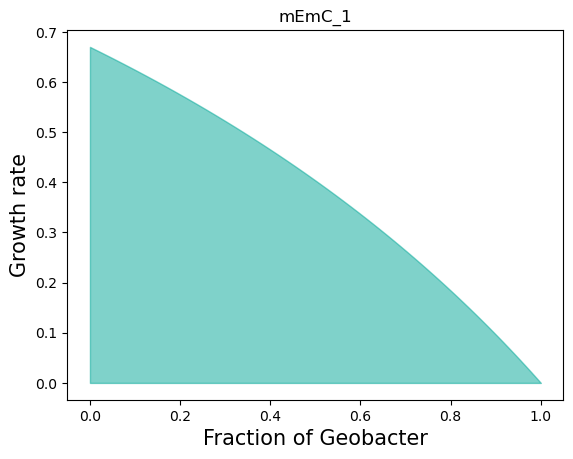

Rhodoferax_fraction_reaction    0.376295
Geobacter_fraction_reaction     0.623705
Name: fluxes, dtype: float64
Geobacter fluxes
Geobacter_TF_so4_Geobacter_e       -0.033359
Geobacter_TF_pi_Geobacter_e        -0.354853
Geobacter_TF_nh4_Geobacter_e       -1.354989
Geobacter_TF_mg2_Geobacter_e       -0.006382
Geobacter_TF_k_Geobacter_e         -0.044301
Geobacter_TF_fe3_Geobacter_e     -176.520565
Geobacter_TF_mal_L_Geobacter_e     -1.965392
Geobacter_TF_h2_Geobacter_e       -93.907806
Geobacter_TF_ca2_Geobacter_e       -0.000188
Name: fluxes, dtype: float64
Geobacter_TF_h_Geobacter_e      173.816204
Geobacter_TF_fe2_Geobacter_e    176.520565
Geobacter_TF_h2o_Geobacter_e      7.484381
Name: fluxes, dtype: float64
Rhodoferax fluxes
Rhodoferax_TF_fe2_Rhodoferax_e    -0.000004
Rhodoferax_TF_fum_Rhodoferax_e    -3.762948
Rhodoferax_TF_h_Rhodoferax_e     -13.758632
Rhodoferax_TF_h2o_Rhodoferax_e    -0.269213
Rhodoferax_TF_nh4_Rhodoferax_e    -1.313933
Rhodoferax_TF_pi_Rhodoferax_e     -0.11215

2026-08-13 14:46:52,333 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:46:53,700 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:46:55,726 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:46:57,081 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:46:59,042 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:47:00,408 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:47:02,412 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:47:03,817 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:47:05,899 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:47:07,355 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:47:09,402 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:47:10,764 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:47:12,994 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:47:14,742 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:47:16,778 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:47:18,131 - PyCoMo - INFO - Logger initialized.
2026-08-

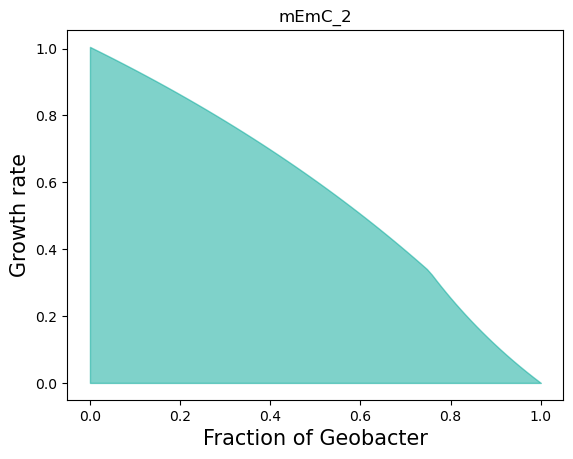

Rhodoferax_fraction_reaction    0.239611
Geobacter_fraction_reaction     0.760389
Name: fluxes, dtype: float64
Geobacter fluxes
Geobacter_TF_so4_Geobacter_e       -0.040670
Geobacter_TF_pi_Geobacter_e        -0.432619
Geobacter_TF_nh4_Geobacter_e       -1.651934
Geobacter_TF_mg2_Geobacter_e       -0.007781
Geobacter_TF_k_Geobacter_e         -0.054009
Geobacter_TF_fe3_Geobacter_e     -217.104331
Geobacter_TF_mal_L_Geobacter_e     -2.396105
Geobacter_TF_h2_Geobacter_e      -115.437337
Geobacter_TF_ca2_Geobacter_e       -0.000229
Name: fluxes, dtype: float64
Geobacter_TF_h_Geobacter_e      213.807312
Geobacter_TF_fe2_Geobacter_e    217.104331
Geobacter_TF_h2o_Geobacter_e      9.124574
Name: fluxes, dtype: float64
Rhodoferax fluxes
Rhodoferax_TF_cit_Rhodoferax_e     -2.396105
Rhodoferax_TF_fe2_Rhodoferax_e     -0.000003
Rhodoferax_TF_h_Rhodoferax_e     -213.807312
Rhodoferax_TF_nh4_Rhodoferax_e     -0.836664
Rhodoferax_TF_pi_Rhodoferax_e      -0.071416
Rhodoferax_TF_so4_Rhodoferax_e     -0

2026-08-13 14:51:03,889 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:51:05,312 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:51:07,750 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:51:09,219 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:51:11,216 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:51:12,573 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:51:14,708 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:51:16,165 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:51:18,188 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:51:19,602 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:51:21,618 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:51:22,982 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:51:25,039 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:51:26,505 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:51:28,579 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:51:29,986 - PyCoMo - INFO - Logger initialized.
2026-08-

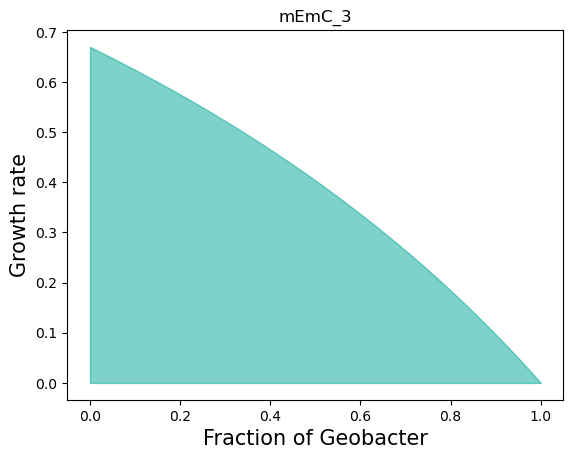

Rhodoferax_fraction_reaction    0.376295
Geobacter_fraction_reaction     0.623705
Name: fluxes, dtype: float64
Geobacter fluxes
Geobacter_TF_so4_Geobacter_e       -0.033359
Geobacter_TF_pi_Geobacter_e        -0.354853
Geobacter_TF_mg2_Geobacter_e       -0.006382
Geobacter_TF_k_Geobacter_e         -0.044301
Geobacter_TF_fe3_Geobacter_e     -623.705232
Geobacter_TF_n2_Geobacter_e        -0.677495
Geobacter_TF_mal_L_Geobacter_e     -1.965392
Geobacter_TF_h2_Geobacter_e      -319.532623
Geobacter_TF_ca2_Geobacter_e       -0.000188
Name: fluxes, dtype: float64
Geobacter_TF_h_Geobacter_e      619.645881
Geobacter_TF_fe2_Geobacter_e    623.705232
Geobacter_TF_h2o_Geobacter_e      7.484381
Name: fluxes, dtype: float64
Rhodoferax fluxes
Rhodoferax_TF_fe2_Rhodoferax_e   -0.000004
Rhodoferax_TF_fum_Rhodoferax_e   -3.762948
Rhodoferax_TF_h_Rhodoferax_e     -2.495104
Rhodoferax_TF_h2o_Rhodoferax_e   -0.269213
Rhodoferax_TF_nh4_Rhodoferax_e   -1.313933
Rhodoferax_TF_pi_Rhodoferax_e    -0.112155
Rhod

2026-08-13 14:55:18,048 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:55:19,811 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:55:21,780 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:55:23,085 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:55:25,048 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:55:26,375 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:55:28,304 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:55:29,598 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:55:31,553 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:55:32,881 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:55:34,763 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:55:36,066 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:55:37,762 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:55:39,156 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:55:40,805 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:55:42,080 - PyCoMo - INFO - Logger initialized.
2026-08-

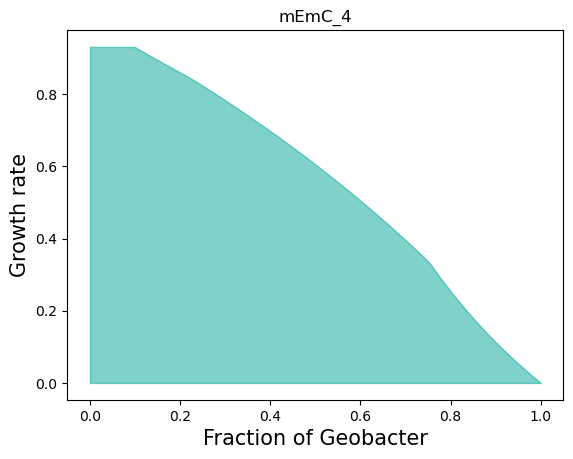

Rhodoferax_fraction_reaction    0.239611
Geobacter_fraction_reaction     0.760389
Name: fluxes, dtype: float64
Geobacter fluxes
Geobacter_TF_so4_Geobacter_e       -0.040670
Geobacter_TF_pi_Geobacter_e        -0.432619
Geobacter_TF_mg2_Geobacter_e       -0.007781
Geobacter_TF_k_Geobacter_e         -0.054009
Geobacter_TF_fe3_Geobacter_e     -289.667924
Geobacter_TF_n2_Geobacter_e        -0.825967
Geobacter_TF_mal_L_Geobacter_e     -2.396105
Geobacter_TF_h2_Geobacter_e      -154.197033
Geobacter_TF_ca2_Geobacter_e       -0.000229
Name: fluxes, dtype: float64
Geobacter_TF_h_Geobacter_e      284.718971
Geobacter_TF_fe2_Geobacter_e    289.667924
Geobacter_TF_h2o_Geobacter_e      9.124574
Name: fluxes, dtype: float64
Rhodoferax fluxes
Rhodoferax_TF_cit_Rhodoferax_e     -2.396105
Rhodoferax_TF_fe2_Rhodoferax_e     -0.000003
Rhodoferax_TF_h_Rhodoferax_e     -239.610524
Rhodoferax_TF_nh4_Rhodoferax_e     -0.836664
Rhodoferax_TF_pi_Rhodoferax_e      -0.071416
Rhodoferax_TF_so4_Rhodoferax_e     -0

2026-08-13 14:58:46,036 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:58:47,371 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:58:49,461 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:58:50,795 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:58:52,737 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:58:54,076 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:58:56,387 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:58:57,666 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:58:59,310 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:59:01,047 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:59:02,719 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:59:04,014 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:59:05,689 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:59:06,968 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:59:08,630 - PyCoMo - INFO - Logger initialized.
2026-08-13 14:59:09,948 - PyCoMo - INFO - Logger initialized.
2026-08-

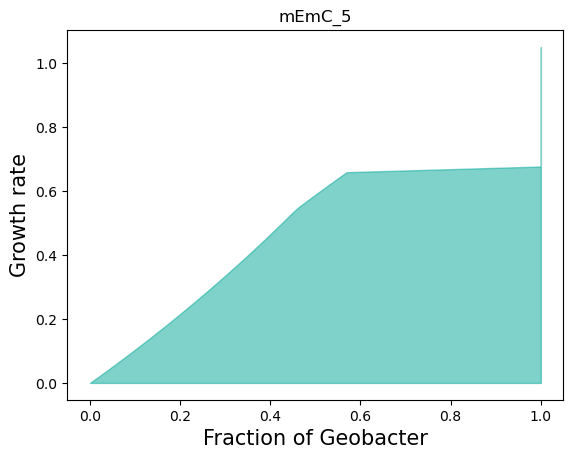

Rhodoferax_fraction_reaction    0.712677
Geobacter_fraction_reaction     0.287323
Name: fluxes, dtype: float64
Geobacter fluxes
Geobacter_TF_so4_Geobacter_e     -0.015368
Geobacter_TF_pi_Geobacter_e      -0.163471
Geobacter_TF_mg2_Geobacter_e     -0.002940
Geobacter_TF_k_Geobacter_e       -0.020408
Geobacter_TF_fe3_Geobacter_e   -214.961908
Geobacter_TF_n2_Geobacter_e      -0.312103
Geobacter_TF_h2_Geobacter_e    -111.018914
Geobacter_TF_cit_Geobacter_e     -2.873232
Geobacter_TF_ca2_Geobacter_e     -0.000086
Name: fluxes, dtype: float64
Geobacter_TF_h_Geobacter_e        213.091880
Geobacter_TF_fe2_Geobacter_e      214.961908
Geobacter_TF_h2o_Geobacter_e        2.011225
Geobacter_TF_mal_L_Geobacter_e      3.404449
Name: fluxes, dtype: float64
Rhodoferax fluxes
Rhodoferax_TF_fe2_Rhodoferax_e     -0.000008
Rhodoferax_TF_h_Rhodoferax_e       -4.667397
Rhodoferax_TF_mal_L_Rhodoferax_e   -3.404449
Rhodoferax_TF_nh4_Rhodoferax_e     -2.488500
Rhodoferax_TF_pi_Rhodoferax_e      -0.212413
Rhod

2026-08-13 15:02:06,343 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:02:07,676 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:02:09,708 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:02:11,013 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:02:13,000 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:02:14,288 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:02:16,426 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:02:17,773 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:02:19,491 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:02:20,859 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:02:22,711 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:02:24,029 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:02:25,670 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:02:26,981 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:02:28,616 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:02:29,920 - PyCoMo - INFO - Logger initialized.
2026-08-

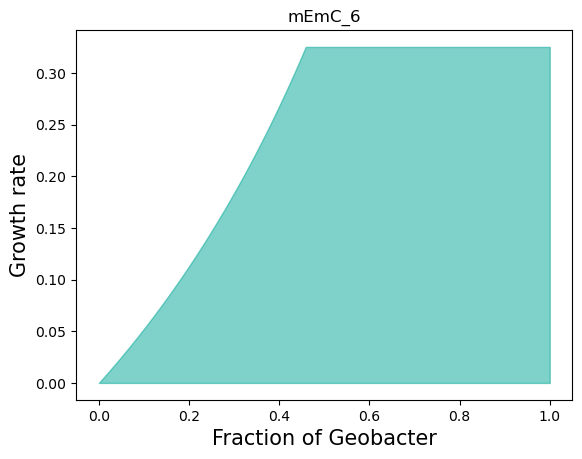

Rhodoferax_fraction_reaction    0.546424
Geobacter_fraction_reaction     0.453576
Name: fluxes, dtype: float64
Geobacter fluxes
Geobacter_TF_so4_Geobacter_e     -0.024260
Geobacter_TF_pi_Geobacter_e      -0.258059
Geobacter_TF_mg2_Geobacter_e     -0.004641
Geobacter_TF_k_Geobacter_e       -0.032217
Geobacter_TF_fe3_Geobacter_e   -339.344587
Geobacter_TF_n2_Geobacter_e      -0.492693
Geobacter_TF_h2_Geobacter_e    -175.257412
Geobacter_TF_cit_Geobacter_e     -4.535761
Geobacter_TF_ca2_Geobacter_e     -0.000137
Name: fluxes, dtype: float64
Geobacter_TF_h_Geobacter_e        336.392512
Geobacter_TF_fe2_Geobacter_e      339.344587
Geobacter_TF_h2o_Geobacter_e        3.174973
Geobacter_TF_mal_L_Geobacter_e      5.374353
Name: fluxes, dtype: float64
Rhodoferax fluxes
Rhodoferax_TF_fe2_Rhodoferax_e     -0.000006
Rhodoferax_TF_h_Rhodoferax_e       -0.680606
Rhodoferax_TF_mal_L_Rhodoferax_e   -5.374353
Rhodoferax_TF_nh4_Rhodoferax_e     -7.525355
Rhodoferax_TF_o2_Rhodoferax_e      -1.270563
Rhod

2026-08-13 15:05:28,430 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:05:29,759 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:05:31,763 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:05:33,082 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:05:35,340 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:05:36,665 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:05:38,325 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:05:39,614 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:05:41,259 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:05:42,564 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:05:44,174 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:05:45,473 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:05:47,097 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:05:48,439 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:05:50,574 - PyCoMo - INFO - Logger initialized.
2026-08-13 15:05:51,870 - PyCoMo - INFO - Logger initialized.
2026-08-

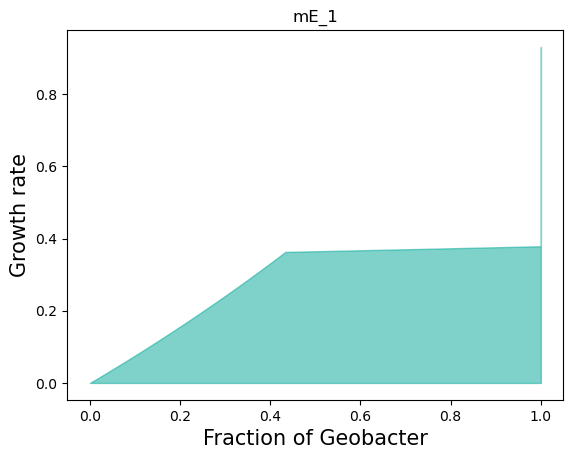

Rhodoferax_fraction_reaction    0.612617
Geobacter_fraction_reaction     0.387383
Name: fluxes, dtype: float64
Geobacter fluxes
Geobacter_TF_so4_Geobacter_e       -0.020720
Geobacter_TF_pi_Geobacter_e        -0.220399
Geobacter_TF_mg2_Geobacter_e       -0.003964
Geobacter_TF_k_Geobacter_e         -0.027515
Geobacter_TF_fe3_Geobacter_e     -387.382799
Geobacter_TF_n2_Geobacter_e        -0.420791
Geobacter_TF_mal_L_Geobacter_e     -3.873828
Geobacter_TF_h2_Geobacter_e      -203.767695
Geobacter_TF_ca2_Geobacter_e       -0.000117
Name: fluxes, dtype: float64
Geobacter_TF_h_Geobacter_e      384.861540
Geobacter_TF_fe2_Geobacter_e    387.382799
Geobacter_TF_h2o_Geobacter_e      7.301667
Geobacter_TF_ac_Geobacter_e       5.306249
Name: fluxes, dtype: float64
Rhodoferax fluxes
Rhodoferax_TF_ac_Rhodoferax_e    -5.306249
Rhodoferax_TF_fe3_Rhodoferax_e   -7.328861
Rhodoferax_TF_nh4_Rhodoferax_e   -2.139115
Rhodoferax_TF_o2_Rhodoferax_e    -0.000888
Rhodoferax_TF_pi_Rhodoferax_e    -0.182590
Rhod

In [11]:
uptake_main = 0.1
results = [] 
flux_results = {}

for pattern in crossfed:
    named_models = pycomo.load_named_models_from_dir(model_dir)
    single_org_models = []
    for modelname, model in named_models.items():
        single_org_model = pycomo.SingleOrganismModel(model, modelname)
        single_org_models.append(single_org_model)

    com_model = pycomo.CommunityModel(single_org_models, community_name)
    com_model.model.solver = "cplex"
    com_model.model.tolerance = 1e-9
    
    feeder = main_c_source[pattern]["feeder"]
    receiver = main_c_source[pattern]["receiver"]
    c_source = main_c_source[pattern]["c_source"]
    crossfed_c_source = main_c_source[pattern]["crossfed"]
    c_sources = [c_source, crossfed_c_source]
    
    medium = get_medium_for_pattern(pattern, dimes, 
                                    c_sources, crossfed, models)
    
    com_model.medium = medium
    com_model.apply_medium()

    implement_dime(pattern, dimes, com_model)
    
    # set uptake rate for main carbon source
    bounds_rxn = com_model.model.reactions.get_by_id(f"{feeder}_fraction_reaction")
    for met, stoich in bounds_rxn.metabolites.items():
        if (f"_{c_source}_" in met.id) and ("_lb" in met.id):
            bounds_rxn.add_metabolites({met: uptake_main}, combine=False)
            print(f"LB set on {met.id}")

        # if (pattern == "mEmC_6") and (feeder == "Geobacter"):
        #     if ("_co2_" in met.id) and ("_lb" in met.id):
        #         print(f"{met.id} forced secretion bound")
        #         bounds_rxn.add_metabolites({met: -0.077196}, combine=False)
            

    bounds_rxn2 = com_model.model.reactions.get_by_id(f"{receiver}_fraction_reaction")
    for met, stoich in bounds_rxn2.metabolites.items():
        if (f"_{crossfed_c_source}_" in met.id) and ("_lb" in met.id):
            bounds_rxn2.add_metabolites({met: uptake_main}, combine=False)
            print(f"LB set on {met.id}")
    
    fba = com_model.max_growth_rate(return_abundances=True, minimal_abundance=0)
    max_mu = fba.loc[fba.reaction_id == "community_biomass"].max_flux.item()
    
    tested_mus = np.linspace(0, max_mu, 60)
    mus, mins, maxs = get_compositions(com_model, tested_mus)
    plot_compositions(mus, mins, maxs, title=pattern)

    # collect rows for this pattern
    for mu, lo, hi in zip(mus, mins, maxs):
        results.append({
            "pattern": pattern,
            "mu": mu,
            "min_fraction": lo,
            "max_fraction": hi,
        })

    com_model.apply_fixed_growth_rate(0.32)

    com_model.model.objective = f"{receiver}_fraction_reaction"
    fluxes = com_model.model.optimize()
    
    flux_results[pattern] = fluxes
    print(fluxes.fluxes[fluxes.fluxes.index.str.endswith("_fraction_reaction")])
    
    f = fluxes.fluxes[fluxes.fluxes.index.str.startswith("Geobacter_TF")]
    print("Geobacter fluxes")
    print(f[f < 0])#/geo_f
    print(f[f > 0])
    f = fluxes.fluxes[fluxes.fluxes.index.str.startswith("Rhodoferax_TF")]
    print("Rhodoferax fluxes")
    print(f[f < 0])#
    print(f[f > 0])
    
results_df = pd.DataFrame(results)
results_df.to_csv("../results/pycomo_composition_ranges.csv", index=False)

In [12]:
for r, f in flux_results["mEmC_5"].fluxes.items():
    if abs(f) > 0:
        print(r, f)
    

Rhodoferax_ALATA_L_Rhodoferax_c -0.13732289031480344
Rhodoferax_ASNS1_Rhodoferax_c 0.05569688573537651
Rhodoferax_ASPTRS_Rhodoferax_c 0.05569688573537651
Rhodoferax_ALARi_Rhodoferax_c 0.011922797047978429
Rhodoferax_ALATRS_Rhodoferax_c 0.11951623397382875
Rhodoferax_A5PISO_Rhodoferax_c 0.01035376790317943
Rhodoferax_ACALDi_Rhodoferax_c 0.46009681550862
Rhodoferax_ACCOAL_Rhodoferax_c 0.08602567176859295
Rhodoferax_GALU_Rhodoferax_c 0.004825676846503894
Rhodoferax_GLYCTO2_Rhodoferax_c 0.011402828087202022
Rhodoferax_PGMT_Rhodoferax_c -0.041269115413201544
Rhodoferax_PPCSCT_Rhodoferax_c 0.08602567176859295
Rhodoferax_ACGK_Rhodoferax_c 0.07813035360101427
Rhodoferax_ACOTA_Rhodoferax_c -0.07813035360101427
Rhodoferax_ADCL_Rhodoferax_c 0.011402828087202022
Rhodoferax_ADCS_Rhodoferax_c 0.011402828087202022
Rhodoferax_AGPR_Rhodoferax_c -0.07813035360101427
Rhodoferax_ANPRT_Rhodoferax_c 0.012763869647690449
Rhodoferax_ANS1_Rhodoferax_c 0.012763869647690449
Rhodoferax_ARGTRS_Rhodoferax_c 0.06846